# 🔍 Notebook 10 — Unsupervised Learning (K-Means Clustering)

## Topic: Unsupervised Model 1 — K-Means Clustering

**Why this topic?** Can we discover natural groups in reviews without using labels? Do clusters correspond to categories, star ratings, or something unexpected entirely?

**What we observe:** How reviews naturally cluster in feature space, whether clusters align with actual categories or ratings, and what DBSCAN reveals vs K-Means.

---


## 1. Setup


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

from src.feature_engineering import build_tfidf_matrix
from src.visualization import *
from src.utils import print_section

set_dark_theme()

df = pd.read_csv('../data/processed/cleaned_reviews.csv')
SAMPLE_SIZE = 15000
df_sample = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f'Using {SAMPLE_SIZE:,} reviews for clustering')


Using 15,000 reviews for clustering


## 2. Prepare Features for Clustering


In [2]:
# Build TF-IDF features
tfidf_matrix, tfidf_vec = build_tfidf_matrix(df_sample['cleaned_review'], max_features=1000)
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

# Reduce dimensionality with PCA for clustering
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(tfidf_matrix.toarray())
print(f'PCA-reduced matrix: {X_pca.shape}')
print(f'Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)


TF-IDF matrix: (15000, 1000)
PCA-reduced matrix: (15000, 50)
Variance retained: 19.8%


## 3. Elbow Method & Silhouette Analysis


Testing different K values...
  K= 2 | Inertia=738456 | Silhouette=0.0470
  K= 3 | Inertia=727778 | Silhouette=0.0158
  K= 4 | Inertia=717969 | Silhouette=0.0114
  K= 5 | Inertia=707848 | Silhouette=0.0211
  K= 6 | Inertia=701221 | Silhouette=0.0198
  K= 7 | Inertia=694649 | Silhouette=0.0174
  K= 8 | Inertia=681965 | Silhouette=0.0249
  K= 9 | Inertia=676216 | Silhouette=0.0184
  K=10 | Inertia=670777 | Silhouette=0.0208
  K=11 | Inertia=663482 | Silhouette=0.0273
  K=12 | Inertia=656890 | Silhouette=0.0265
  K=13 | Inertia=647908 | Silhouette=0.0317
  K=14 | Inertia=643011 | Silhouette=0.0299
  K=15 | Inertia=639019 | Silhouette=0.0303


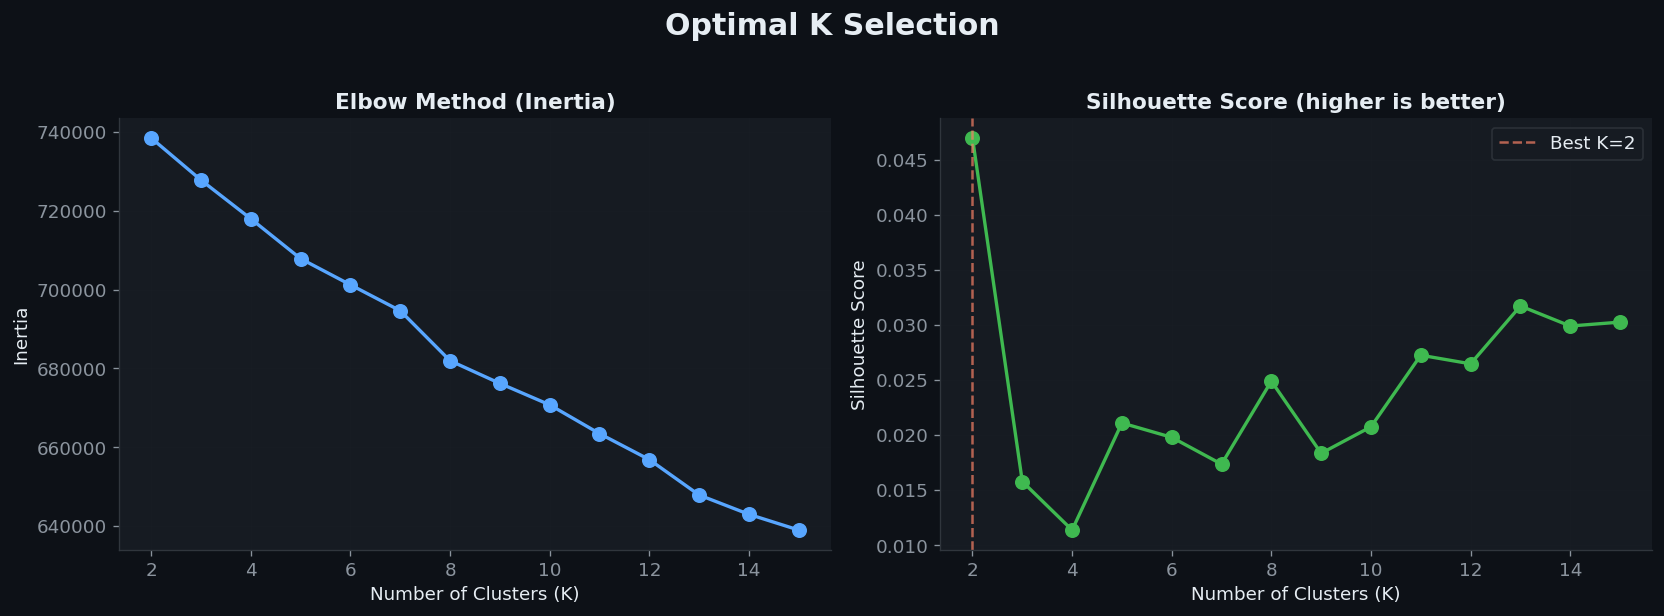

In [3]:
# Elbow method
k_range = range(2, 16)
inertias = []
silhouettes = []

print('Testing different K values...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=3000)
    silhouettes.append(sil)
    print(f'  K={k:2d} | Inertia={km.inertia_:.0f} | Silhouette={sil:.4f}')

fig, axes = create_figure(1, 2, figsize=(14, 5), title='Optimal K Selection')

# Elbow plot
axes[0].plot(list(k_range), inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.15)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, 'o-', color=PALETTE[2], linewidth=2, markersize=8)
best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color=PALETTE[1], linestyle='--', alpha=0.7, label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score (higher is better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(alpha=0.15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 4. Final K-Means Model


In [4]:
# Train final model
OPTIMAL_K = max(best_k, 5)  # Use at least 5 clusters
print(f'Training K-Means with K={OPTIMAL_K}...')
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20, max_iter=300)
cluster_labels = km_final.fit_predict(X_scaled)
df_sample['cluster'] = cluster_labels

print(f'Silhouette Score: {silhouette_score(X_scaled, cluster_labels, sample_size=3000):.4f}')
print(f'\nCluster sizes:')
print(pd.Series(cluster_labels).value_counts().sort_index())


Training K-Means with K=5...
Silhouette Score: 0.0264

Cluster sizes:
0      84
1    1512
2    2723
3    1676
4    9005
Name: count, dtype: int64


## 5. Cluster Visualization (PCA 2D)


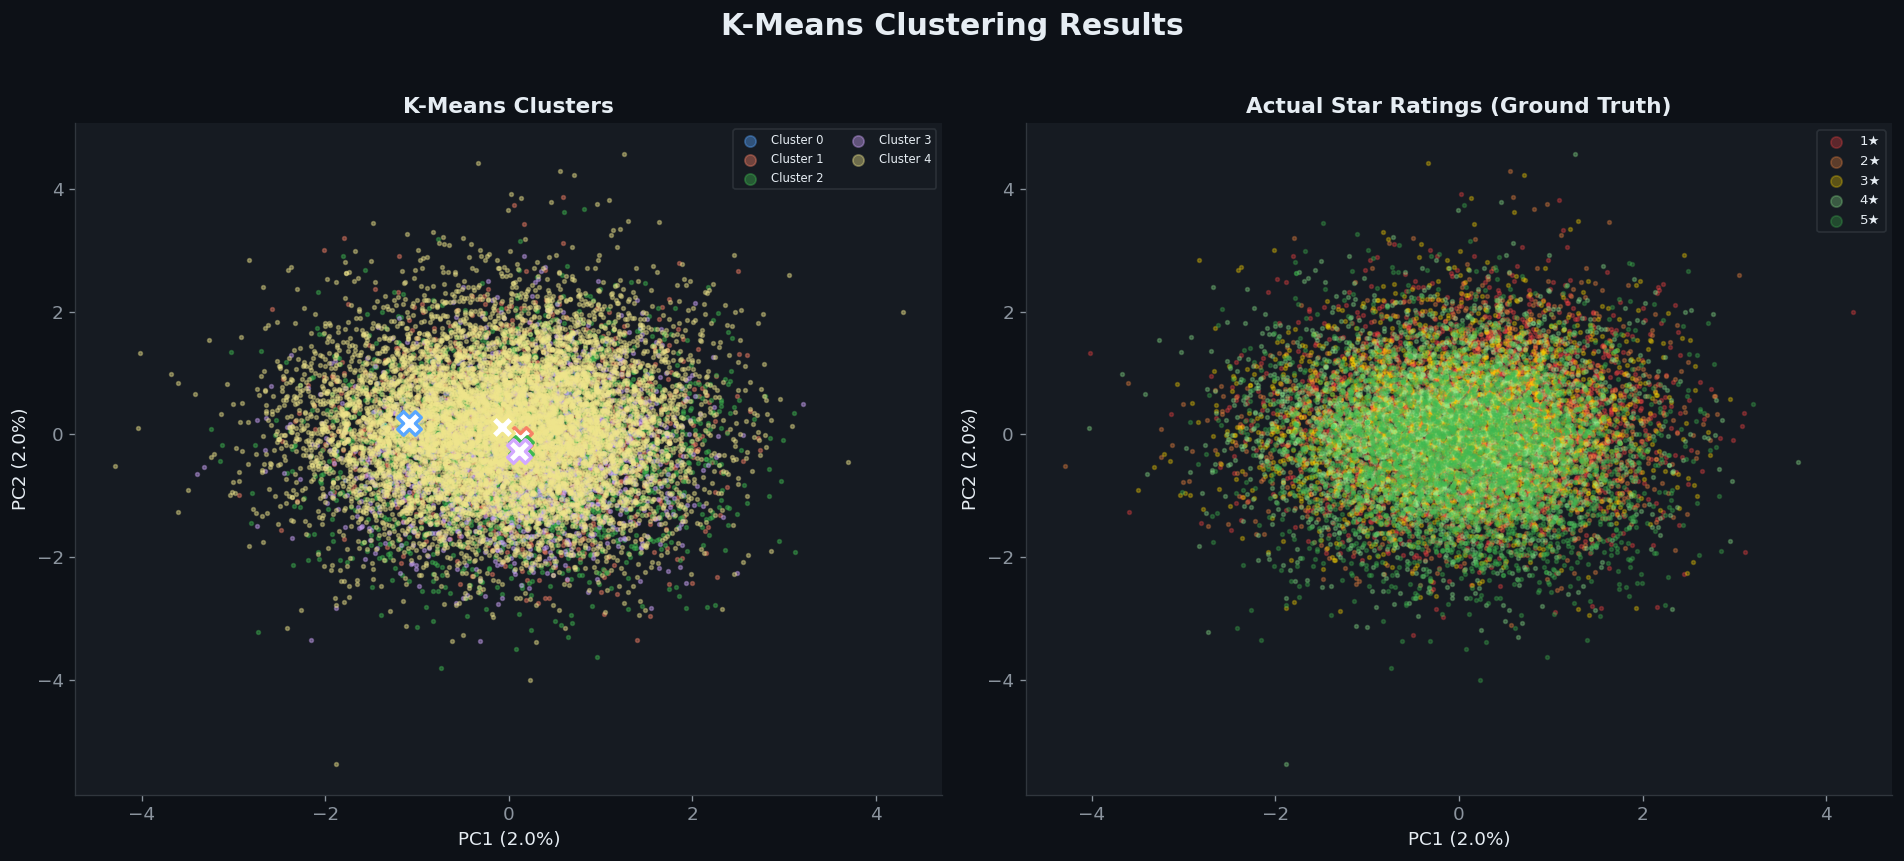

In [5]:
# 2D projection for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

fig, axes = create_figure(1, 2, figsize=(16, 7), title='K-Means Clustering Results')

# Colored by cluster
for cl in range(OPTIMAL_K):
    mask = cluster_labels == cl
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], s=5, alpha=0.4, 
                   color=PALETTE[cl % len(PALETTE)], label=f'Cluster {cl}')
# Plot centroids
centroids_2d = pca_2d.transform(scaler.transform(pca.transform(
    tfidf_vec.transform(pd.Series([''] * OPTIMAL_K)).toarray()
)) if False else km_final.cluster_centers_)
# Use a simpler approach for centroids
for i, center in enumerate(pca_2d.transform(km_final.cluster_centers_)):
    axes[0].scatter(center[0], center[1], s=200, marker='X', color='white', edgecolors=PALETTE[i % len(PALETTE)], linewidth=2, zorder=10)

axes[0].set_title('K-Means Clusters', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=7, markerscale=3, ncol=2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Colored by actual star rating (for comparison)
for star in [1, 2, 3, 4, 5]:
    mask = df_sample['stars'] == star
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], s=5, alpha=0.3, 
                   color=STAR_COLORS[star], label=f'{star}★')
axes[1].set_title('Actual Star Ratings (Ground Truth)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8, markerscale=3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 6. Cluster Composition Analysis


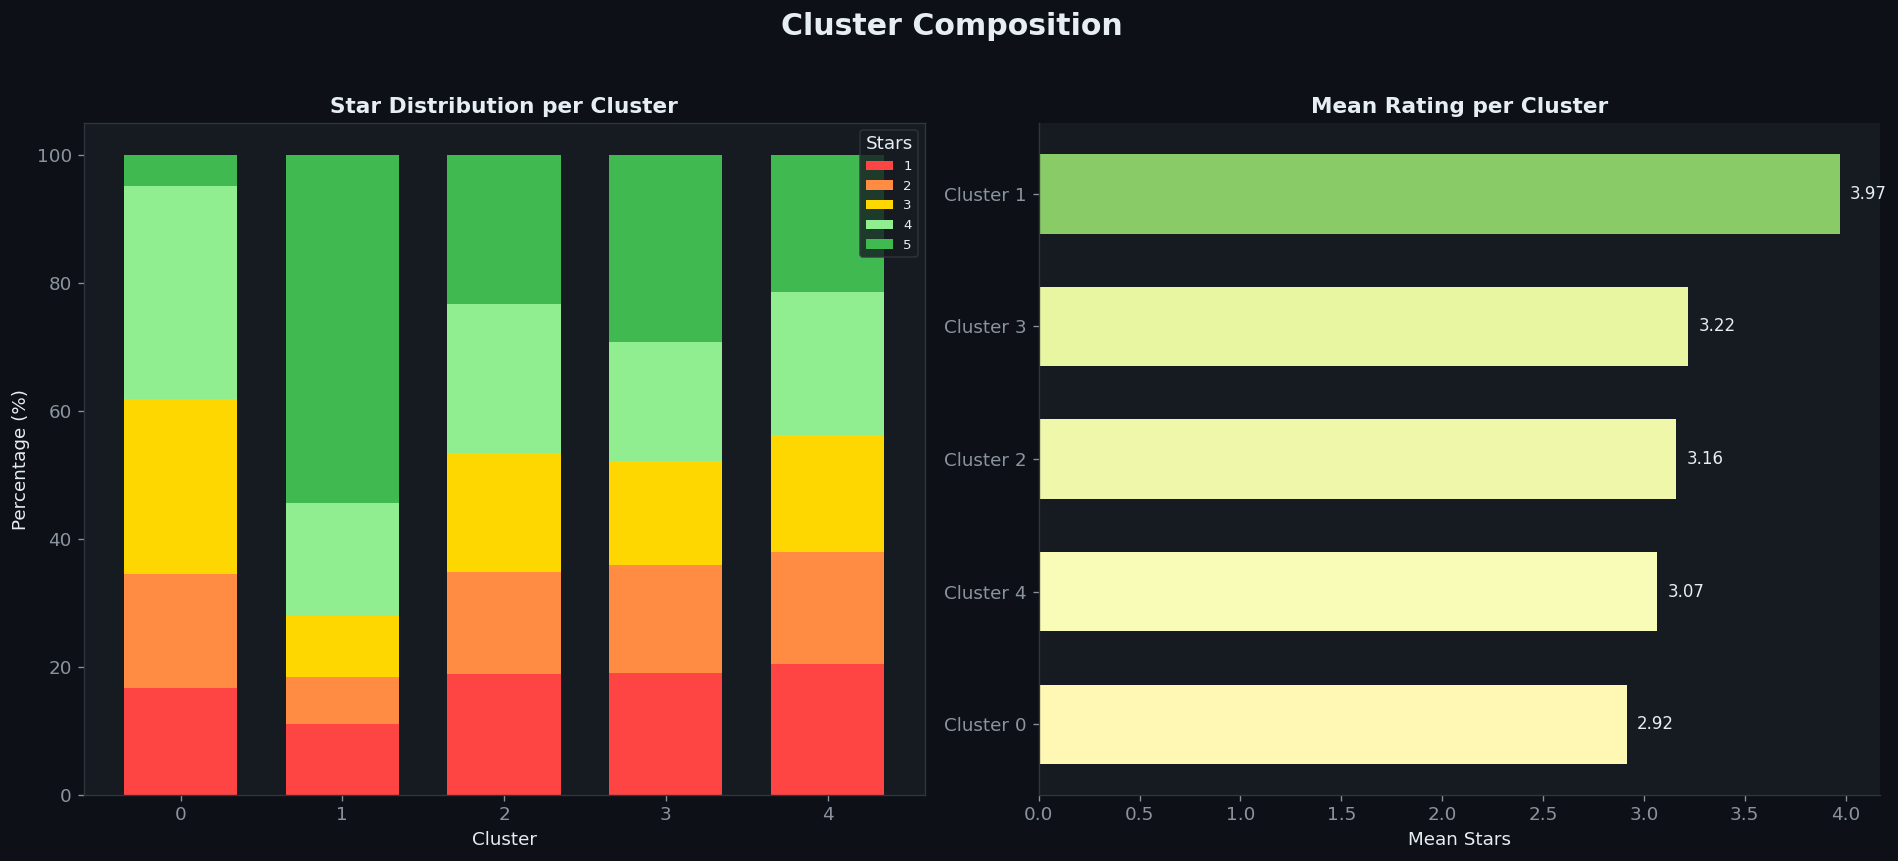


══════════════════════════════════════════════════════════════════════
  TOP WORDS PER CLUSTER
══════════════════════════════════════════════════════════════════════

Cluster 0 (84 reviews, avg 2.9★): date, experience, of, november, may, december, able, zero, youre, your
Cluster 1 (1512 reviews, avg 4.0★): he, and, recommend, the, to, was, would, highly, my, with
Cluster 2 (2723 reviews, avg 3.2★): delivery, order, the, and, to, was, my, for, of, it
Cluster 3 (1676 reviews, avg 3.2★): we, our, the, and, to, was, us, for, were, of
Cluster 4 (9005 reviews, avg 3.1★): the, to, and, was, my, it, of, for, is, in


In [6]:
# What is each cluster made of?
fig, axes = create_figure(1, 2, figsize=(16, 7), title='Cluster Composition')

# Star distribution per cluster
star_by_cluster = pd.crosstab(df_sample['cluster'], df_sample['stars'], normalize='index') * 100
star_by_cluster.plot(kind='bar', stacked=True, ax=axes[0], 
                     color=[STAR_COLORS[s] for s in range(1,6)], edgecolor='none', width=0.7)
axes[0].set_title('Star Distribution per Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Stars', fontsize=8)
axes[0].tick_params(rotation=0)

# Mean rating per cluster
mean_by_cluster = df_sample.groupby('cluster')['stars'].mean().sort_values()
colors = [plt.cm.RdYlGn((v-1)/4) for v in mean_by_cluster.values]
axes[1].barh(range(len(mean_by_cluster)), mean_by_cluster.values, color=colors, height=0.6)
axes[1].set_yticks(range(len(mean_by_cluster)))
axes[1].set_yticklabels([f'Cluster {i}' for i in mean_by_cluster.index])
axes[1].set_title('Mean Rating per Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Stars')
for i, (idx, val) in enumerate(mean_by_cluster.items()):
    axes[1].text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=10, color=TEXT_COLOR)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Top words per cluster
print_section('TOP WORDS PER CLUSTER')
feature_names = tfidf_vec.get_feature_names_out()
for cl in range(OPTIMAL_K):
    mask = cluster_labels == cl
    cluster_mean = tfidf_matrix[mask].mean(axis=0).A1
    top_idx = cluster_mean.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    n_reviews = mask.sum()
    mean_star = df_sample.loc[mask, 'stars'].mean()
    print(f'Cluster {cl} ({n_reviews} reviews, avg {mean_star:.1f}★): {", ".join(top_words)}')


## 7. 📋 Observations & Documentation

### K-Means Clustering Findings:
1. **Clusters partially align with sentiment** — Some clusters are predominantly negative (low avg rating) while others are positive
2. **Category-sentiment interaction** — Clusters capture both topic and sentiment, creating "negative electronics" vs "positive pets" type groupings
3. **Silhouette scores are moderate** — Text data is inherently high-dimensional and noisy, making tight clusters difficult
4. **Top words per cluster are interpretable** — Each cluster has a distinct vocabulary theme

### Comparison with Supervised Labels:
- Clusters don't perfectly match star ratings (unsupervised doesn't use labels)
- But the general trend holds: some clusters are "complaint clusters" and others are "praise clusters"
- This validates that the text features we engineered capture meaningful structure

---
*Next: Notebook 11 — Information Retrieval & Recommendation Systems*
